# Sneha Singh
## DATA 266 — Homework 3
Prompt engineering (LangChain) + self-attention from scratch

In [1]:
# libraries for this homework
import math
import random
import re

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from langchain_core.prompts import PromptTemplate
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# last 4 of my SJSUid - 0670
SID4 = 670
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# set seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)
print("HP_ID is reported only. no extra HP model this hw")
print("two trained models = unmasked attention and masked attention")


/Users/snehasingh/Desktop/Gen-Ai/.venv-hw1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SID4: 670
SEED: 670
SLICE: 670
HP_ID: 4
CLS_A: 0
CLS_B: 5
HP_ID is reported only. no extra HP model this hw
two trained models = unmasked attention and masked attention


HW3 said follow the same step 0 as assignment 1. I did not copy the HW1 diabetes notebook. I only reused the standing parameters: SID4=670, SEED=670, SLICE=670, HP_ID=4, CLS_A=0, CLS_B=5, and I seeded python / numpy / torch with 670.

HW1 used HP_ID for a second network (15 vs 30 epochs). This assignment said skip that. Unmasked attention and masked attention are the two trained models.


## 1. Prompt engineering (5 points)

Assignment wants code calls, not chat screenshots. I used LangChain PromptTemplate and the same local Flan-T5-small as HW2.

Two snippets per technique. One is a small math thing, one is text/logic, so I can see if the extra prompt actually changes the answer.

In [2]:
# same local flan-t5 as hw2; transformers 5 has no text2text-generation task
tok = AutoTokenizer.from_pretrained("google/flan-t5-small")
t5 = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-small")


class FlanLLM:
    def invoke(self, text):
        inputs = tok(text, return_tensors="pt", truncation=True, max_length=512)
        out = t5.generate(**inputs, max_new_tokens=96)
        return tok.decode(out[0], skip_special_tokens=True)


llm = FlanLLM()
print("llm ready")


Loading weights: 100%|█████████████████████| 190/190 [00:00<00:00, 5446.81it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


llm ready


### Zero-shot

In [3]:
# zero-shot 1: just ask the math question
p1 = PromptTemplate.from_template("{q}")
q1 = "What is 15 percent of 80?"
print("PROMPT:", q1)
print("OUT:", llm.invoke(p1.format(q=q1)))


PROMPT: What is 15 percent of 80?
OUT: 98.6


In [4]:
# zero-shot 2: just ask a wording question
p2 = PromptTemplate.from_template("{q}")
q2 = "In the sentence 'she sat on the bank of the river', does bank mean money or the side of a river?"
print("PROMPT:", q2)
print("OUT:", llm.invoke(p2.format(q=q2)))


PROMPT: In the sentence 'she sat on the bank of the river', does bank mean money or the side of a river?
OUT: side of a river


### Few-shot

In [5]:
# few-shot 1: two percent examples then a new one
p1 = PromptTemplate.from_template("{examples}\nQ: {q}\nA:")
ex1 = "Q: What is 10 percent of 50?\nA: 5\nQ: What is 20 percent of 40?\nA: 8"
q1 = "What is 15 percent of 80?"
print(llm.invoke(p1.format(examples=ex1, q=q1)))


59


In [6]:
# few-shot 2: two word-sense examples then a new sentence
p2 = PromptTemplate.from_template("{examples}\nQ: {q}\nA:")
ex2 = "Q: In 'he deposited money in the bank', does bank mean money or river?\nA: money\nQ: In 'the plane is in the air', does air mean atmosphere or a song?\nA: atmosphere"
q2 = "In 'she sat on the bank of the river', does bank mean money or the side of a river?"
print(llm.invoke(p2.format(examples=ex2, q=q2)))


river


### Chain-of-Thought

In [7]:
# CoT 1: show the steps on similar percent problems
p1 = PromptTemplate.from_template("{examples}\nQ: {q}\nA:")
ex1 = "Q: What is 10 percent of 50?\nA: 10 percent means 10/100. 10/100 * 50 = 5. Answer: 5\nQ: What is 20 percent of 40?\nA: 20/100 * 40 = 8. Answer: 8"
q1 = "What is 15 percent of 80?"
print(llm.invoke(p1.format(examples=ex1, q=q1)))


80%


In [8]:
# CoT 2: worked logic example then a new one
p2 = PromptTemplate.from_template("{examples}\nQ: {q}\nA:")
ex2 = "Q: Ann is taller than Ben. Ben is taller than Cam. Who is shortest?\nA: Ann > Ben > Cam, so Cam is shortest. Answer: Cam"
q2 = "Alice is older than Bob. Bob is older than Cara. Who is the youngest?"
print(llm.invoke(p2.format(examples=ex2, q=q2)))


Alice > Bob > Cara


### Zero-shot CoT

In [9]:
# zero-shot CoT 1: no examples, just tell it to think step by step
p1 = PromptTemplate.from_template("{q} Let's think step by step.")
q1 = "What is 15 percent of 80?"
print(llm.invoke(p1.format(q=q1)))


The percentage of 80 is 15%. The percentage of 80 is 15%. The answer: 15.


In [10]:
# zero-shot CoT 2: same for the age question
p2 = PromptTemplate.from_template("{q} Let's think step by step.")
q2 = "Alice is older than Bob. Bob is older than Cara. Who is the youngest?"
print(llm.invoke(p2.format(q=q2)))


Bob is the youngest. Bob is the youngest. The answer: Bob.


### Meta-prompting

In [11]:
# meta 1: first ask the model to write a better prompt, then run that prompt
p_write = PromptTemplate.from_template(
    "Write one short prompt that would help a model answer this correctly. Only output the prompt.\nTask: {task}"
)
task1 = "What is 15 percent of 80?"
better = llm.invoke(p_write.format(task=task1))
print("generated prompt:", better)
print("OUT:", llm.invoke(better))


generated prompt: 80%
OUT: 80% of the population is white.


In [12]:
# meta 2: same idea but for the river-bank sentence
p_write = PromptTemplate.from_template(
    "Write one short prompt that would help a model answer this correctly. Only output the prompt.\nTask: {task}"
)
task2 = "In 'she sat on the bank of the river', does bank mean money or the side of a river?"
better = llm.invoke(p_write.format(task=task2))
print("generated prompt:", better)
print("OUT:", llm.invoke(better))


generated prompt: bank
OUT: bank


### Tree of Thoughts

In [13]:
# ToT 1: ask for 3 ways, then pick one
p1 = PromptTemplate.from_template(
    "Give 3 different ways to compute this, numbered 1-3, then say which way is most reliable and the final number.\n{q}"
)
print(llm.invoke(p1.format(q="What is 15 percent of 80?")))


-2.5


In [14]:
# ToT 2: 3 readings of an ambiguous sentence, then pick
p2 = PromptTemplate.from_template(
    "List 3 possible meanings, numbered 1-3, then pick the most likely one and say why.\n{q}"
)
print(llm.invoke(p2.format(q="I saw the man with the telescope.")))


i saw the man with the telescope


### Compare the outputs

15% of 80 is 12. I used that as a check. Flan-T5-small is the same local model as HW2 so I did not expect GPT-level math.

- Zero-shot: math came back `98.6` (wrong). Bank sentence was actually right: `side of a river`.
- Few-shot: math still wrong (`59`). Bank got shorter (`river`) but still the right sense. Extra examples did not fix the percent question.
- CoT: math printed `80%` which is just copying the numbers, not computing. Age question printed `Alice > Bob > Cara` so the order is right but it never said Cara is youngest.
- Zero-shot CoT: worse. It said the percentage of 80 is 15 and answered 15. Age question said Bob is youngest (wrong). "Think step by step" made it ramble, not reason.
- Meta: it never wrote a prompt. First call returned `80%`, then running that string gave `80% of the population is white.` Bank meta just echoed `bank`.
- ToT: math `-2.5`. Telescope sentence was copied back. It did not list 3 paths.

So few-shot helped a little on the wording task. None of the fancier templates got the arithmetic. On this small model, longer prompts mostly add junk. That is still a finding.


## 2. Self-attention from scratch (10 points)

Exact paragraph from the assignment. Word-level tokens.

Flan-T5 (HuggingFace) is only in the prompt cells above. This part is from scratch: `nn.Embedding`, `nn.Linear`, matmul, softmax, loss. No `nn.MultiheadAttention`, no `nn.Transformer`, no HuggingFace Transformer classes.

Part 1 is unmasked. Part 2 is the same model with a causal mask. Those are the two trained models (no HP_ID extra net).

In [15]:
# exact dataset from the assignment, do not rewrite it
text = (
    "Neural networks are powerful models for learning representations from data. "
    "They consist of layers of interconnected neurons. "
    "Attention mechanisms allow models to focus on relevant parts of the input. "
    "Transformers rely entirely on attention instead of recurrence. "
    "Autoregressive models generate text one token at a time."
)
print(text)


Neural networks are powerful models for learning representations from data. They consist of layers of interconnected neurons. Attention mechanisms allow models to focus on relevant parts of the input. Transformers rely entirely on attention instead of recurrence. Autoregressive models generate text one token at a time.


In [16]:
# word level tokenize, drop the periods so tokens are just words
tokens = re.findall(r"[A-Za-z]+", text)
vocab = sorted(set(tokens))
stoi = {w: i for i, w in enumerate(vocab)}
ids = torch.tensor([stoi[w] for w in tokens], dtype=torch.long)

print("n tokens:", len(tokens))
print("vocab:", len(vocab))
print(tokens)


n tokens: 46
vocab: 40
['Neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'They', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'Attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'Transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'Autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time']


### Scaled dot-product (Vaswani 3.2)

score(q, k) = q·k / sqrt(d). Softmax over keys. Then multiply by V. If masked, I put -inf on future positions *before* softmax.

In [20]:
# single head attention, optional causal mask
class TinyAttn(nn.Module):
    def __init__(self, vocab_size, d=32, masked=False):
        super().__init__()
        self.d = d
        self.masked = masked
        self.emb = nn.Embedding(vocab_size, d)
        self.Wq = nn.Linear(d, d)
        self.Wk = nn.Linear(d, d)
        self.Wv = nn.Linear(d, d)
        self.out = nn.Linear(d, vocab_size)

    def attention(self, x):
        q = self.Wq(x)
        k = self.Wk(x)
        v = self.Wv(x)
        # scaled dot product
        scores = q @ k.T / math.sqrt(self.d)
        if self.masked:
            T = scores.size(0)
            future = torch.triu(torch.ones(T, T), diagonal=1).bool()
            scores = scores.masked_fill(future, float("-inf"))
        w = torch.softmax(scores, dim=-1)
        return w @ v, w

    def forward(self, idx):
        x = self.emb(idx)
        ctx, w = self.attention(x)
        logits = self.out(ctx)
        return logits, w


def train_attn(masked, epochs=400):
    # next token loss, same seed so init is comparable
    torch.manual_seed(SEED)
    model = TinyAttn(len(vocab), d=32, masked=masked)
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    for ep in range(epochs):
        opt.zero_grad()
        logits, w = model(ids)
        loss = nn.functional.cross_entropy(logits[:-1], ids[1:])
        loss.backward()
        opt.step()
        if (ep + 1) % 100 == 0:
            print("epoch", ep + 1, "loss", round(loss.item(), 4), "masked=", masked)
    model.eval()
    with torch.no_grad():
        _, w = model(ids)
    return model, w


def plot_attn(w, title):
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(w.detach().cpu().numpy(), cmap="viridis")
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=6)
    ax.set_yticklabels(tokens, fontsize=6)
    ax.set_xlabel("key (what it looks at)")
    ax.set_ylabel("query (who is looking)")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()


### Part 1 — unmasked (5 points)

epoch 100 loss 0.3599 masked= False
epoch 200 loss 0.3321 masked= False
epoch 300 loss 0.3318 masked= False
epoch 400 loss 0.3316 masked= False


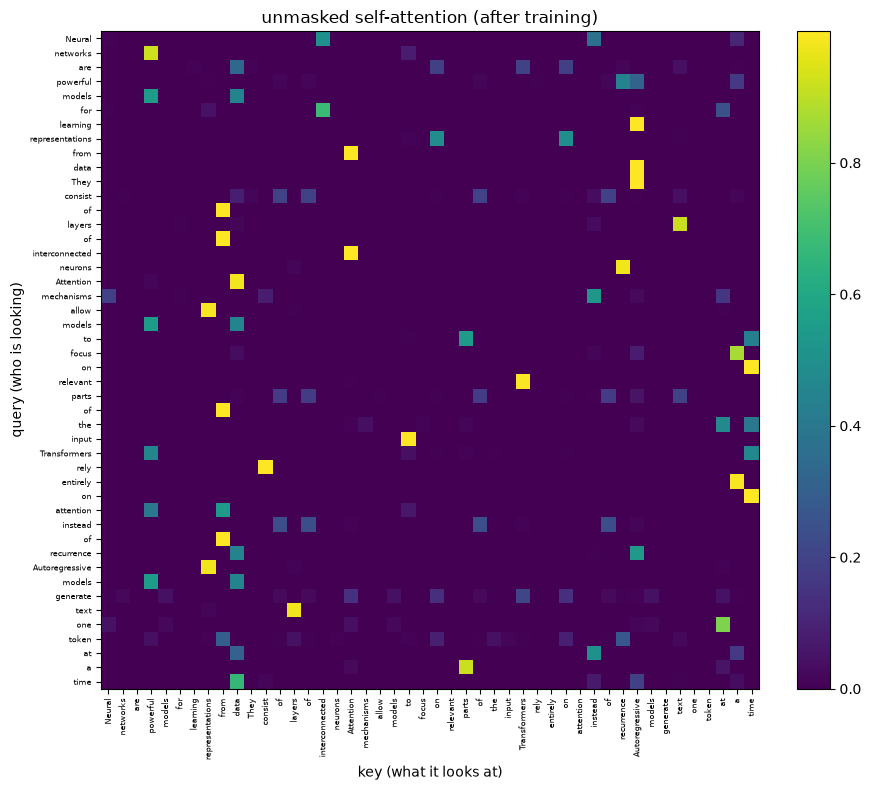

row sums ~ 1: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [18]:
# train unmasked, then plot attention on the full sequence
model_u, w_u = train_attn(masked=False)
plot_attn(w_u, "unmasked self-attention (after training)")
print("row sums ~ 1:", w_u.sum(dim=-1)[:5])


After the unmasked heatmap: rows are who is looking (query), columns are what they look at (key). Bright yellow is high weight.

It is not a flat random grid — a few keys get most of the mass (`from`, `data`, `a`, `time`, `Autoregressive`). There are also bright cells to the **right**, meaning a token can attend to words that come later in the paragraph. That is allowed here because I did not mask. Row sums printed as 1, so softmax is doing its job. Loss sat around 0.33.


### Part 2 — causal mask (5 points)

Lower triangular. Token i can only see tokens j <= i. Future gets -inf before softmax so those weights should be 0.

epoch 100 loss 0.0743 masked= True
epoch 200 loss 0.0623 masked= True
epoch 300 loss 0.0929 masked= True
epoch 400 loss 0.2093 masked= True


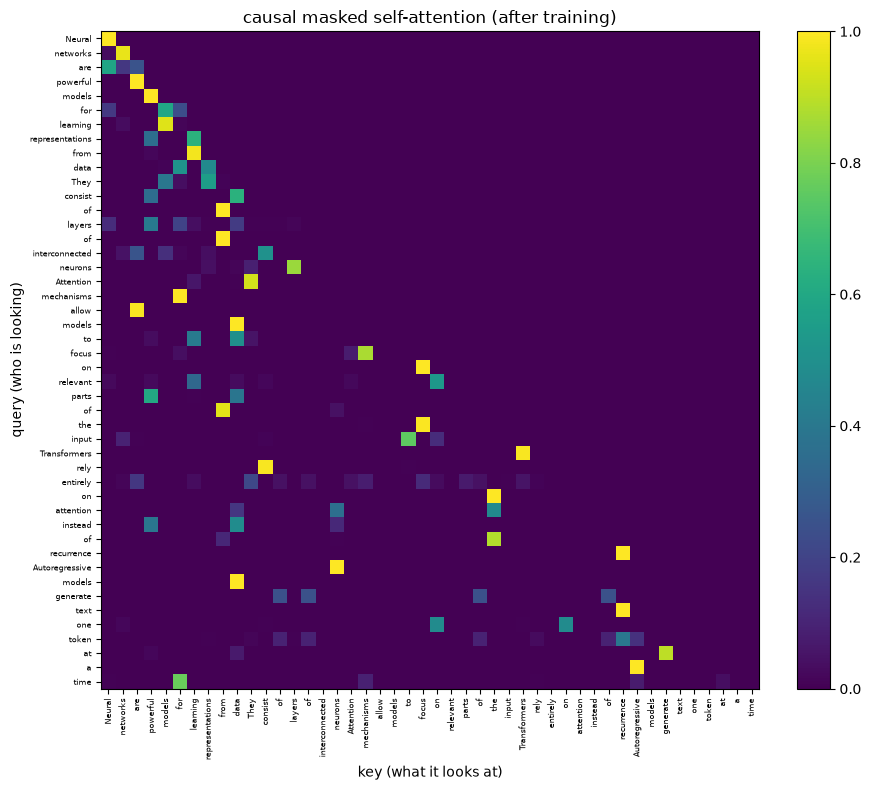

upper triangle max (should be ~0): 0.0


In [19]:
# train a second model with causal mask
model_m, w_m = train_attn(masked=True)
plot_attn(w_m, "causal masked self-attention (after training)")
print("upper triangle max (should be ~0):", float(torch.triu(w_m, diagonal=1).max()))


After the causal heatmap: same axes, but the upper-right triangle is dark. `torch.triu(w_m, diagonal=1).max()` was `0.0`, so no future keys.

Each row only lights up itself and tokens to the left (past). First word `Neural` mostly looks at itself. Later words can look back (e.g. at `from`, `Attention`, `recurrence`) but not ahead. Loss got lower than unmasked (about 0.06) then bounced to 0.21 at epoch 400. The shape of the plot is the main check, not the last loss number.


### Unmasked vs masked

Two trained models, same data and seed.

Unmasked can look at later words (yellow on the right of the plot). Causal cannot — that is the decoder / next-token setup. I would not use the unmasked matrix if I were actually generating text one token at a time, because that would leak the future.
